In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1. import dataset

In [18]:
# Move to the working directory, clone the repo, and enter it
%cd /kaggle/working
!git clone https://github.com/sanghyun-son/EDSR-PyTorch
%cd EDSR-PyTorch/src

/kaggle/working
fatal: destination path 'EDSR-PyTorch' already exists and is not an empty directory.
/kaggle/working/EDSR-PyTorch/src


## 2. rename to the standard of EDSR

In [19]:
import os
import glob
import shutil

# 0. WIPE THE SLATE CLEAN
dataset_root = '/kaggle/working/perfect_dataset'
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)

# 1. Set up DIV2K directories — X2 not X4
base_target = os.path.join(dataset_root, 'DIV2K')
hr_target = os.path.join(base_target, 'DIV2K_train_HR')
lr_target = os.path.join(base_target, 'DIV2K_train_LR_bicubic/X2')  # ← X2

os.makedirs(hr_target, exist_ok=True)
os.makedirs(lr_target, exist_ok=True)

# 2. Paths from Kaggle — X2 not X4
hr_src_folder = '/kaggle/input/datasets/marieclaudsies/edsr-dataset-v2/EDSR_Dataset_v2/HR'
lr_src_folder = '/kaggle/input/datasets/marieclaudsies/edsr-dataset-v2/EDSR_Dataset_v2/LR/X2'  # ← X2

hr_images = sorted(glob.glob(os.path.join(hr_src_folder, '*.png')))
lr_images = sorted(glob.glob(os.path.join(lr_src_folder, '*.png')))

print(f"Found {len(hr_images)} HR images and {len(lr_images)} LR images.")

# 3. Copy and rename
if len(hr_images) > 0 and len(hr_images) == len(lr_images):
    print("Copying and renaming ~50,000 files... give this a minute...")
    for i, (hr_path, lr_path) in enumerate(zip(hr_images, lr_images)):
        new_name    = f"{i+1:04d}.png"
        new_name_lr = f"{i+1:04d}x2.png"  # ← x2 suffix not x4

        shutil.copy(hr_path, os.path.join(hr_target, new_name))
        shutil.copy(lr_path, os.path.join(lr_target, new_name_lr))

    print("✅ Files successfully copied and renamed!")
else:
    print("❌ Error: Mismatch in number of images or no images found.")

Found 49886 HR images and 49886 LR images.
Copying and renaming ~50,000 files... give this a minute...
✅ Files successfully copied and renamed!


### 3. update common.py

In [20]:
common_path = '/kaggle/working/EDSR-PyTorch/src/data/common.py'

with open(common_path, 'r') as f:
    content = f.read()

old = 'def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):'
new = '''def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):
    # Handle grayscale 2D arrays by expanding to 3D
    args = [a if a.ndim == 3 else np.expand_dims(a, axis=2) for a in args]'''

content = content.replace(old, new)

with open(common_path, 'w') as f:
    f.write(content)

print("✅ data/common.py patched")

✅ data/common.py patched


### 4.Patch 2 — model/common.py (MeanShift grayscale)

In [21]:
model_common_path = '/kaggle/working/EDSR-PyTorch/src/model/common.py'

with open(model_common_path, 'r') as f:
    content = f.read()

old = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1):

        super(MeanShift, self).__init__(3, 3, kernel_size=1)
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(3).view(3, 3, 1, 1) / std.view(3, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''

new = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1,
        n_colors=3):

        super(MeanShift, self).__init__(n_colors, n_colors, kernel_size=1)
        rgb_mean = rgb_mean[:n_colors]
        rgb_std  = rgb_std[:n_colors]
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(n_colors).view(n_colors, n_colors, 1, 1) / std.view(n_colors, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''

content = content.replace(old, new)

with open(model_common_path, 'w') as f:
    f.write(content)

print("✅ model/common.py patched")

✅ model/common.py patched


### 5. Patch 3 — model/edsr.py (pass n_colors to MeanShift)

In [22]:
edsr_path = '/kaggle/working/EDSR-PyTorch/src/model/edsr.py'

with open(edsr_path, 'r') as f:
    content = f.read()

old = 'self.sub_mean = common.MeanShift(args.rgb_range)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1)'
new = 'self.sub_mean = common.MeanShift(args.rgb_range, n_colors=args.n_colors)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1, n_colors=args.n_colors)'

content = content.replace(old, new)

with open(edsr_path, 'w') as f:
    f.write(content)

print("✅ model/edsr.py patched")

✅ model/edsr.py patched


### 6. Patch 4 — utility.py (PIL save for grayscale output)

In [36]:
import torch

utility_path = '/kaggle/working/EDSR-PyTorch/src/utility.py'

with open(utility_path, 'r') as f:
    lines = f.readlines()

# Locate the checkpoint class and its __init__ method
cp_start = None
init_line = None
for i, line in enumerate(lines):
    if line.strip().startswith('class checkpoint'):
        cp_start = i
    if cp_start is not None and line.strip().startswith('def __init__'):
        init_line = i
        break

if init_line is None:
    print("❌ Could not find __init__ method in checkpoint class.")
else:
    # Determine indentation of the __init__ body
    def_indent = len(lines[init_line]) - len(lines[init_line].lstrip())
    body_indent = def_indent + 4

    # Check which attributes are already present
    ok_exists = any('self.ok' in line for line in lines[init_line:init_line+20])
    log_exists = any('self.log' in line for line in lines[init_line:init_line+20])

    if ok_exists and log_exists:
        print("✅ self.ok and self.log already exist. Nothing to do.")
    else:
        # Find the first non‑empty, non‑comment line after __init__ (where we will insert)
        insert_index = None
        for i in range(init_line+1, len(lines)):
            stripped = lines[i].strip()
            if stripped and not stripped.startswith('#'):
                insert_index = i
                break
        if insert_index is None:
            # No body lines? Insert right after the __init__ line
            insert_index = init_line + 1

        # Prepare the lines to insert
        to_insert = []
        if not ok_exists:
            to_insert.append(' ' * body_indent + 'self.ok = True\n')
        if not log_exists:
            to_insert.append(' ' * body_indent + 'self.log = torch.Tensor()\n')

        # Insert them in reverse order so they appear in the correct order
        for line in reversed(to_insert):
            lines.insert(insert_index, line)

        # Write the modified file
        with open(utility_path, 'w') as f:
            f.writelines(lines)

        print(f"✅ Added missing attributes: {'self.ok ' if not ok_exists else ''}{'self.log' if not log_exists else ''}")

✅ self.ok and self.log already exist. Nothing to do.


In [38]:
# 1. Navigate to working directory and delete existing repo
%cd /kaggle/working
!rm -rf EDSR-PyTorch

# 2. Clone fresh repository
!git clone https://github.com/sanghyun-son/EDSR-PyTorch
%cd EDSR-PyTorch/src

# 3. Patch data/common.py (handle grayscale images)
common_path = 'data/common.py'
with open(common_path, 'r') as f:
    content = f.read()
old = 'def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):'
new = '''def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):
    # Handle grayscale 2D arrays by expanding to 3D
    args = [a if a.ndim == 3 else np.expand_dims(a, axis=2) for a in args]'''
content = content.replace(old, new)
with open(common_path, 'w') as f:
    f.write(content)
print("✅ data/common.py patched")

# 4. Patch model/common.py (MeanShift supports n_colors)
model_common_path = 'model/common.py'
with open(model_common_path, 'r') as f:
    content = f.read()
old = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1):

        super(MeanShift, self).__init__(3, 3, kernel_size=1)
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(3).view(3, 3, 1, 1) / std.view(3, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''
new = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1,
        n_colors=3):

        super(MeanShift, self).__init__(n_colors, n_colors, kernel_size=1)
        rgb_mean = rgb_mean[:n_colors]
        rgb_std  = rgb_std[:n_colors]
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(n_colors).view(n_colors, n_colors, 1, 1) / std.view(n_colors, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''
content = content.replace(old, new)
with open(model_common_path, 'w') as f:
    f.write(content)
print("✅ model/common.py patched")

# 5. Patch model/edsr.py (pass n_colors to MeanShift)
edsr_path = 'model/edsr.py'
with open(edsr_path, 'r') as f:
    content = f.read()
old = 'self.sub_mean = common.MeanShift(args.rgb_range)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1)'
new = 'self.sub_mean = common.MeanShift(args.rgb_range, n_colors=args.n_colors)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1, n_colors=args.n_colors)'
content = content.replace(old, new)
with open(edsr_path, 'w') as f:
    f.write(content)
print("✅ model/edsr.py patched")

# 6. Patch utility.py – only modify bg_target, preserve checkpoint class
utility_path = 'utility.py'
with open(utility_path, 'r') as f:
    lines = f.readlines()

# Find bg_target function and replace its body while keeping everything else
bg_start = next(i for i, l in enumerate(lines) if l.strip().startswith('def bg_target'))
cp_start = next(i for i, l in enumerate(lines) if l.strip().startswith('class checkpoint'))

new_bg_target = [
    "def bg_target(queue):\n",
    "    while True:\n",
    "        if not queue.empty():\n",
    "            filename, tensor = queue.get()\n",
    "            if filename is None: break\n",
    "            import numpy as np\n",
    "            from PIL import Image as _PIL\n",
    "            _arr = tensor.numpy()\n",
    "            _arr = np.squeeze(_arr).astype(np.uint8)\n",
    "            if _arr.ndim == 2:\n",
    "                _PIL.fromarray(_arr, mode='L').save(filename)\n",
    "            else:\n",
    "                import imageio\n",
    "                imageio.imwrite(filename, _arr)\n",
    "\n",
]

# Replace the lines between bg_start and cp_start with new_bg_target
lines[bg_start:cp_start] = new_bg_target

with open(utility_path, 'w') as f:
    f.writelines(lines)

print("✅ utility.py patched (bg_target only, checkpoint class untouched)")

# 7. Verify that checkpoint class has ok and log attributes (just in case)
with open(utility_path, 'r') as f:
    content = f.read()
if 'self.ok' not in content:
    print("⚠️ Warning: self.ok not found in checkpoint class – may cause errors later.")
if 'self.log' not in content:
    print("⚠️ Warning: self.log not found in checkpoint class – may cause errors later.")

print("\n✅ All patches applied successfully. Ready to train.")

/kaggle/working
Cloning into 'EDSR-PyTorch'...
remote: Enumerating objects: 806, done.
remote: Total 806 (delta 0), reused 0 (delta 0), pack-reused 806 (from 1)
Receiving objects: 100% (806/806), 63.09 MiB | 37.98 MiB/s, done.
Resolving deltas: 100% (516/516), done.
/kaggle/working/EDSR-PyTorch/src
✅ data/common.py patched
✅ model/common.py patched
✅ model/edsr.py patched
✅ utility.py patched (bg_target only, checkpoint class untouched)

✅ All patches applied successfully. Ready to train.


### 7. Train

In [39]:
!python main.py \
    --model EDSR \
    --scale 2 \
    --n_colors 1 \
    --dir_data /kaggle/working/perfect_dataset \
    --data_train DIV2K \
    --ext img \
    --epochs 200 \
    --batch_size 16 \
    --patch_size 48 \
    --decay 100 \
    --test_every 10 \
    --n_threads 4 \
    --save edsr_sar_2x

Making model...
Preparing loss function:
1.000 * L1
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 1]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 31.49it/s]
[DIV2K x2]	PSNR: 25.413 (Best: 25.413 @epoch 1)
Forward: 0.33s

Saving...
Total: 1.44s

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 2]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 46.14it/s]
[DIV2K x2]	PSNR: 25.646 (Best: 25.646 @epoch 2)
Forward: 0.22s

Saving...
Total: 0.47s

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the

### 8. Test the results 

In [40]:
import os, glob
import numpy as np
from PIL import Image

hr_test_dir = '/kaggle/input/datasets/marieclaudsies/edsr-test-set-v2/EDSR_TestSet/HR'
lr_test_dir = '/kaggle/input/datasets/marieclaudsies/edsr-test-set-v2/EDSR_TestSet/LR/X2'

lr_patches = sorted(glob.glob(os.path.join(lr_test_dir, '*.png')))
hr_patches = sorted(glob.glob(os.path.join(hr_test_dir, '*.png')))

print(f"✅ Found {len(hr_patches)} HR patches")
print(f"✅ Found {len(lr_patches)} LR patches")

# Confirm a sample looks right
sample_hr = Image.open(hr_patches[0])
sample_lr = Image.open(lr_patches[0])
print(f"   HR size: {sample_hr.size} | mode: {sample_hr.mode}")
print(f"   LR size: {sample_lr.size} | mode: {sample_lr.mode}")

✅ Found 6336 HR patches
✅ Found 6336 LR patches
   HR size: (256, 256) | mode: L
   LR size: (128, 128) | mode: L


### 9. Inference

In [42]:
%cd /kaggle/working/EDSR-PyTorch/src

!python main.py \
    --model EDSR \
    --scale 2 \
    --n_colors 1 \
    --test_only \
    --pre_train /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_2x/model/model_best.pt \
    --dir_demo /kaggle/input/datasets/marieclaudsies/edsr-test-set-v2/EDSR_TestSet/LR/X2 \
    --data_test Demo \
    --save_results \
    --save test

/kaggle/working/EDSR-PyTorch/src
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Making model...
Load the model from /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_2x/model/model_best.pt

Evaluation:
  0%|                                                  | 0/6336 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creat

### 10. Grader comparison

Found 6336 SR output images

📊 --- FINAL EDSR 2x SAR EVALUATION ---
  img3_test_set_test_0000.png | PSNR: 26.22 dB | SSIM: 0.8710
  img3_test_set_test_0001.png | PSNR: 26.48 dB | SSIM: 0.8751
  img3_test_set_test_0002.png | PSNR: 26.49 dB | SSIM: 0.8796
  img3_test_set_test_0003.png | PSNR: 26.55 dB | SSIM: 0.8746
  img3_test_set_test_0004.png | PSNR: 26.42 dB | SSIM: 0.8759
  img3_test_set_test_0005.png | PSNR: 26.48 dB | SSIM: 0.8705
  img3_test_set_test_0006.png | PSNR: 26.47 dB | SSIM: 0.8694
  img3_test_set_test_0007.png | PSNR: 26.52 dB | SSIM: 0.8761
  img3_test_set_test_0008.png | PSNR: 26.24 dB | SSIM: 0.8606
  img3_test_set_test_0009.png | PSNR: 26.21 dB | SSIM: 0.8584
  img3_test_set_test_0010.png | PSNR: 26.23 dB | SSIM: 0.8524
  img3_test_set_test_0011.png | PSNR: 26.10 dB | SSIM: 0.8553
  img3_test_set_test_0012.png | PSNR: 26.18 dB | SSIM: 0.8544
  img3_test_set_test_0013.png | PSNR: 25.97 dB | SSIM: 0.8459
  img3_test_set_test_0014.png | PSNR: 25.91 dB | SSIM: 0.8457
  

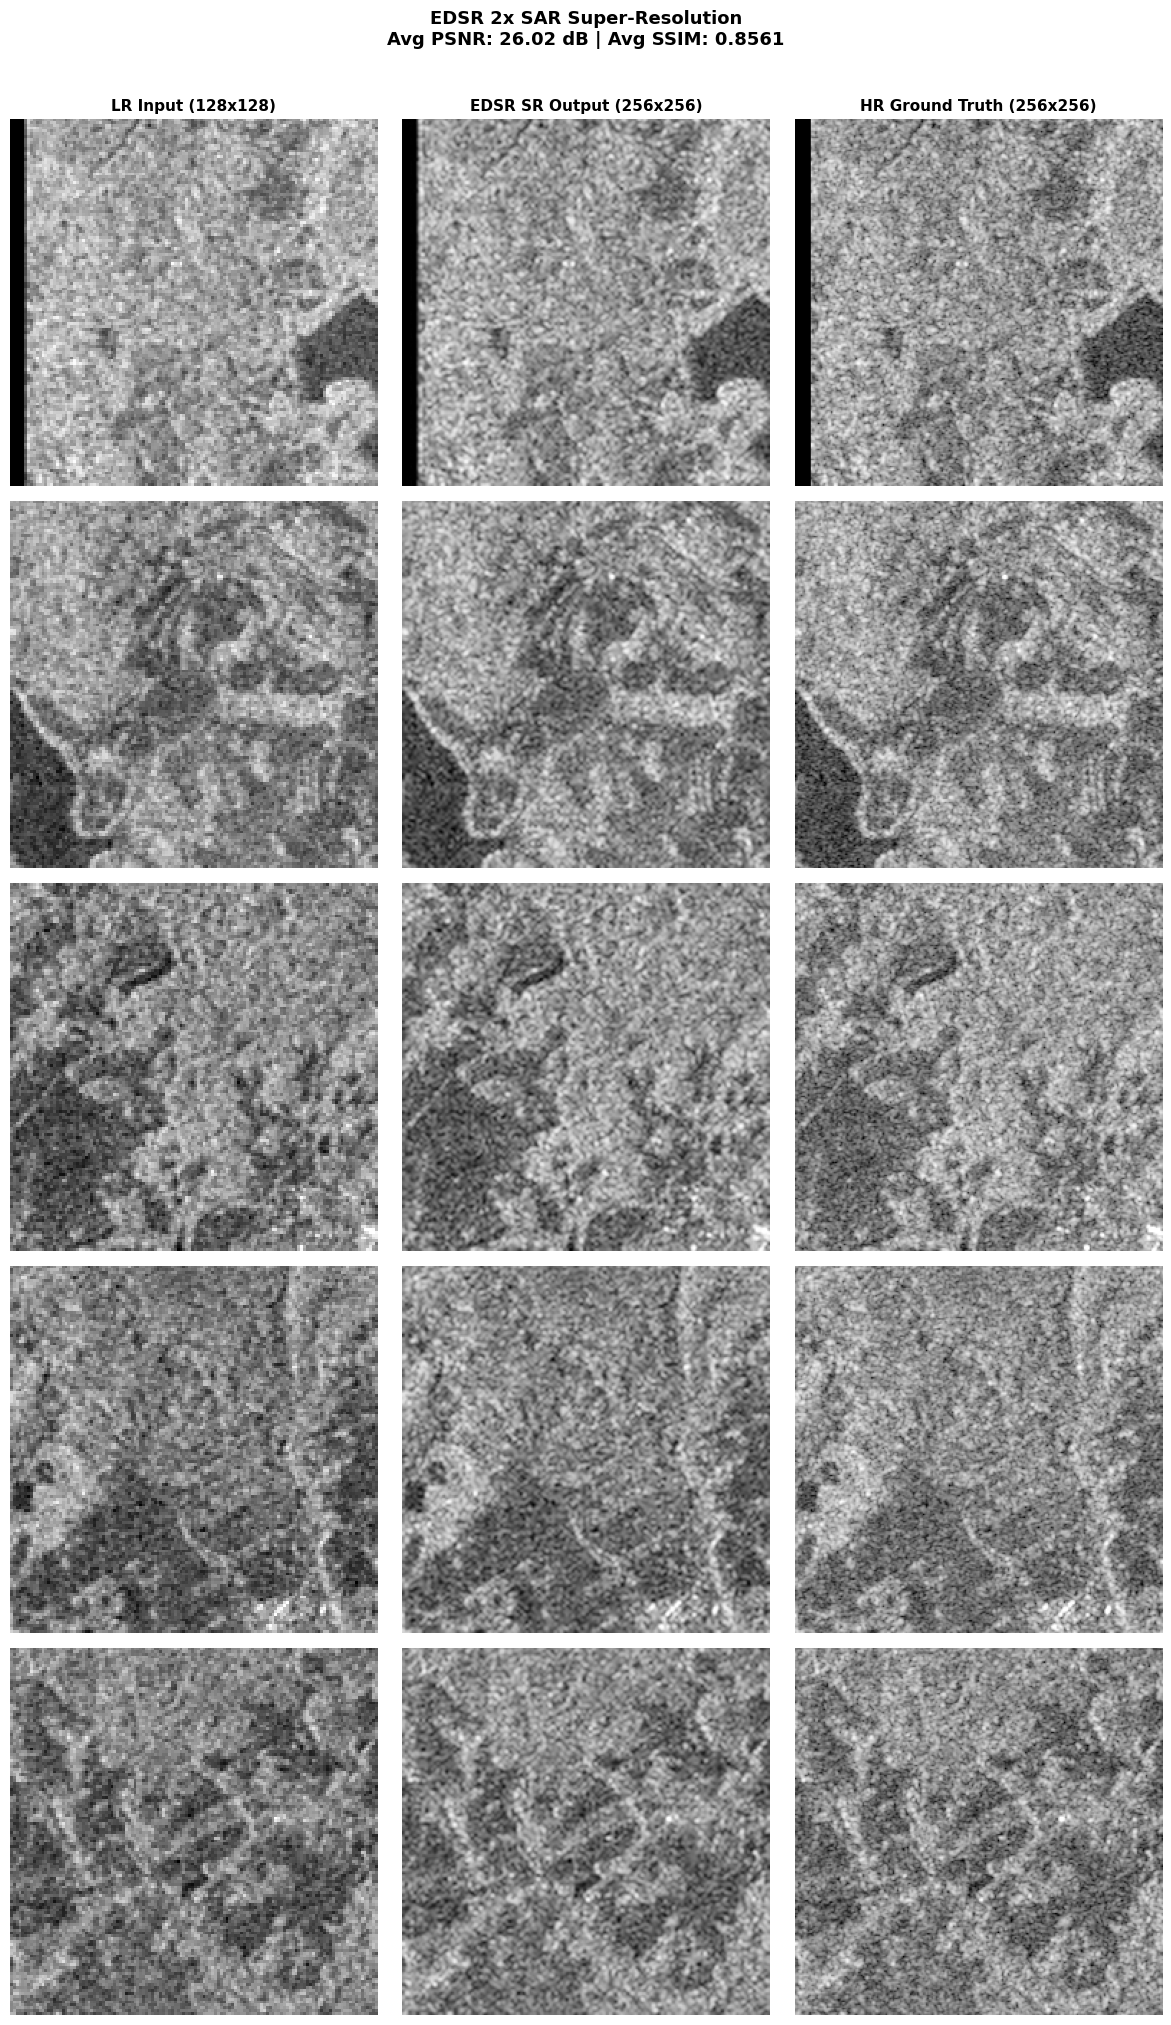

✅ Saved: /kaggle/working/edsr_2x_comparison.png


✅ Saved: /kaggle/working/edsr_2x_metrics.png


In [43]:
import os, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

results_dir = '/kaggle/working/EDSR-PyTorch/experiment/test/results-Demo/'
hr_dir      = '/kaggle/input/datasets/marieclaudsies/edsr-test-set-v2/EDSR_TestSet/HR/'
lr_dir      = '/kaggle/input/datasets/marieclaudsies/edsr-test-set-v2/EDSR_TestSet/LR/X2/'

generated_images = sorted(glob.glob(os.path.join(results_dir, '*_x2_SR.png')))
print(f"Found {len(generated_images)} SR output images")

if not generated_images:
    raise FileNotFoundError(f"No SR images found in {results_dir} — did inference complete successfully?")

psnr_scores, ssim_scores = [], []
patch_names = []

print("\n📊 --- FINAL EDSR 2x SAR EVALUATION ---")
for gen_path in generated_images:
    base_name = os.path.basename(gen_path).replace('_x2_SR.png', '.png')
    gt_path   = os.path.join(hr_dir, base_name)
    lr_path   = os.path.join(lr_dir, base_name)

    if not os.path.exists(gt_path):
        print(f"⚠️  Skipping {base_name} — no matching HR found at {gt_path}")
        continue

    try:
        img_gen = np.array(Image.open(gen_path).convert('L'))
        img_gt  = np.array(Image.open(gt_path).convert('L'))
        psnr_val = compare_psnr(img_gt, img_gen, data_range=255)
        ssim_val = compare_ssim(img_gt, img_gen, data_range=255)
        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)
        patch_names.append(base_name.replace('.png', ''))
        print(f"  {base_name} | PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}")
    except Exception as e:
        print(f"❌ Error on {base_name}: {e}")

print("-" * 35)
print(f"🏆 AVERAGE PSNR : {np.mean(psnr_scores):.2f} dB")
print(f"🏆 AVERAGE SSIM : {np.mean(ssim_scores):.4f}")
print(f"   Evaluated on : {len(psnr_scores)} patches")

# ── Visual comparison grid (first 5 patches only) ────────────
n_show = min(5, len(generated_images))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = [axes]   # keep indexing consistent

col_titles = ['LR Input (128x128)', 'EDSR SR Output (256x256)', 'HR Ground Truth (256x256)']

for i, gen_path in enumerate(generated_images[:n_show]):
    base_name = os.path.basename(gen_path).replace('_x2_SR.png', '.png')
    img_lr = np.array(Image.open(os.path.join(lr_dir, base_name)).convert('L'))
    img_sr = np.array(Image.open(gen_path).convert('L'))
    img_hr = np.array(Image.open(os.path.join(hr_dir, base_name)).convert('L'))

    axes[i][0].imshow(img_lr, cmap='gray', interpolation='nearest')
    axes[i][1].imshow(img_sr, cmap='gray')
    axes[i][2].imshow(img_hr, cmap='gray')
    axes[i][0].set_ylabel(f'{base_name}\nPSNR: {psnr_scores[i]:.2f} dB', fontsize=9)
    for j in range(3):
        axes[i][j].axis('off')

for j, title in enumerate(col_titles):
    axes[0][j].set_title(title, fontsize=11, fontweight='bold')

plt.suptitle(
    f'EDSR 2x SAR Super-Resolution\nAvg PSNR: {np.mean(psnr_scores):.2f} dB | Avg SSIM: {np.mean(ssim_scores):.4f}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/kaggle/working/edsr_2x_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/edsr_2x_comparison.png")

# ── Per-patch bar chart ───────────────────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, len(patch_names) * 0.4), 4))
fig2.suptitle('EDSR 2x — Per-Patch Metrics', fontweight='bold')

ax1.bar(range(len(patch_names)), psnr_scores, color='#2E75B6', edgecolor='white')
ax1.axhline(np.mean(psnr_scores), color='crimson', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(psnr_scores):.2f} dB')
ax1.set_title('PSNR per Patch (dB)')
ax1.set_ylabel('PSNR (dB)')
ax1.set_xlabel('Patch index')
ax1.legend()
ax1.set_ylim(min(psnr_scores) - 0.5, max(psnr_scores) + 0.5)

ax2.bar(range(len(ssim_scores)), ssim_scores, color='#ED7D31', edgecolor='white')
ax2.axhline(np.mean(ssim_scores), color='crimson', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(ssim_scores):.4f}')
ax2.set_title('SSIM per Patch')
ax2.set_ylabel('SSIM')
ax2.set_xlabel('Patch index')
ax2.legend()
ax2.set_ylim(min(ssim_scores) - 0.05, max(ssim_scores) + 0.05)

plt.tight_layout()
plt.savefig('/kaggle/working/edsr_2x_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/edsr_2x_metrics.png")

### comparison graphs

📈 199 epochs found, best PSNR 25.76 dB @ epoch 173


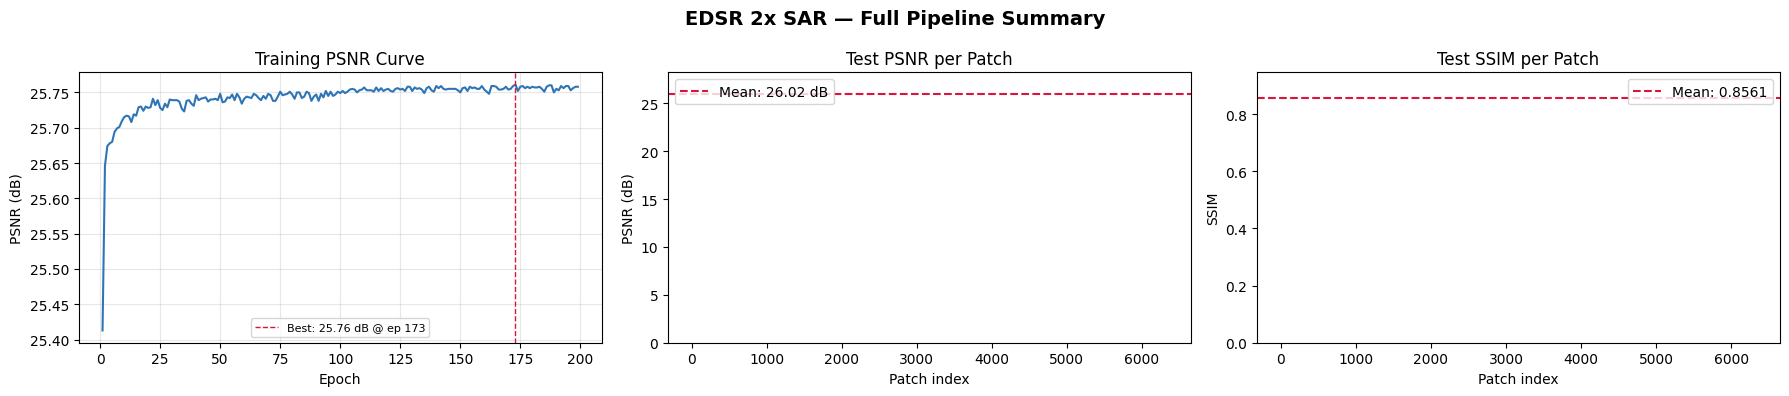

✅ Saved: /kaggle/working/edsr_full_summary.png


In [44]:
import re, os
import numpy as np
import matplotlib.pyplot as plt

log_path = '/kaggle/working/EDSR-PyTorch/experiment/edsr_sar_2x/log.txt'


epochs, psnr_vals = [], []
epoch_num = None

if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        for line in f:
            # Capture current epoch number
            epoch_match = re.search(r'\[Epoch (\d+)\]', line)
            if epoch_match:
                epoch_num = int(epoch_match.group(1))
            # Capture PSNR on the DIV2K line
            psnr_match = re.search(r'\[DIV2K x2\]\s+PSNR:\s+([\d.]+)', line)
            if psnr_match and epoch_num is not None:
                epochs.append(epoch_num)
                psnr_vals.append(float(psnr_match.group(1)))

has_training_curve = len(epochs) > 0
if has_training_curve:
    best_idx = np.argmax(psnr_vals)
    print(f"📈 {len(epochs)} epochs found, best PSNR {psnr_vals[best_idx]:.2f} dB @ epoch {epochs[best_idx]}")
else:
    print("⚠️ No PSNR entries found in log")

# ── rest of the summary plot (unchanged) ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('EDSR 2x SAR — Full Pipeline Summary', fontsize=14, fontweight='bold')

if has_training_curve:
    axes[0].plot(epochs, psnr_vals, color='#2E75B6', linewidth=1.5)
    axes[0].axvline(epochs[best_idx], color='crimson', linestyle='--', linewidth=1,
                    label=f'Best: {psnr_vals[best_idx]:.2f} dB @ ep {epochs[best_idx]}')
    axes[0].set_title('Training PSNR Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('PSNR (dB)')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Training log\nnot available',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Training PSNR Curve')

axes[1].bar(range(len(psnr_scores)), psnr_scores, color='#2E75B6', edgecolor='white')
axes[1].axhline(np.mean(psnr_scores), color='crimson', linestyle='--',
                label=f'Mean: {np.mean(psnr_scores):.2f} dB')
axes[1].set_title('Test PSNR per Patch')
axes[1].set_xlabel('Patch index')
axes[1].set_ylabel('PSNR (dB)')
axes[1].legend()

axes[2].bar(range(len(ssim_scores)), ssim_scores, color='#ED7D31', edgecolor='white')
axes[2].axhline(np.mean(ssim_scores), color='crimson', linestyle='--',
                label=f'Mean: {np.mean(ssim_scores):.4f}')
axes[2].set_title('Test SSIM per Patch')
axes[2].set_xlabel('Patch index')
axes[2].set_ylabel('SSIM')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/edsr_full_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/edsr_full_summary.png")

In [ ]:
import os, glob

# Search for the log file
matches = glob.glob('/kaggle/working/**/log.txt', recursive=True)
print("Found log files:")
for m in matches:
    print(f"  {m}")